# Exoplanet Detection Project
## Data Preprocessing & Cleaning

**Author:** Mann  
**Date:** March 2026  
**Dataset:** Kepler Labelled Time Series Data  
**Goal:** Normalize light curves, remove noise, handle class imbalance using SMOTE, and prepare final train/val/test splits.

## 1. Load Data & Initial Audit

In this step, we load the Kepler training and testing datasets using Pandas.  
We also inspect dataset shape, check for missing values, and examine the class distribution to understand the severe imbalance between planet and non-planet stars.

In [3]:
import pandas as pd
import numpy as np

# Load your dataset
train = pd.read_csv("../data/raw/exoTrain.csv")
test = pd.read_csv("../data/raw/exoTest.csv")

# Audit
print("Train shape:", train.shape)
print("Test shape: ", test.shape)
print("\nMissing values in train:\n", train.isnull().sum().sum())
print("Missing values in test: ",  test.isnull().sum().sum())
print("\nClass distribution (train):\n", train['LABEL'].value_counts())

Train shape: (5087, 3198)
Test shape:  (570, 3198)

Missing values in train:
 0
Missing values in test:  0

Class distribution (train):
 LABEL
1    5050
2      37
Name: count, dtype: int64


## 2. Split Features & Labels

Here we separate:
- **Flux measurements** → input features (`X`)
- **Planet labels** → target values (`y`)

The original dataset labels are:
- `1 = non-planet`
- `2 = confirmed planet`

These are remapped into standard binary labels:
- `0 = non-planet`
- `1 = planet`

This conversion is important for machine learning models and evaluation metrics.

In [4]:
from sklearn.preprocessing import StandardScaler

# Step 2 — Split Features & Labels
X_train = train.drop("LABEL", axis=1).values
y_train = train["LABEL"].values

X_test = test.drop("LABEL", axis=1).values
y_test = test["LABEL"].values

# ── CRITICAL FIX ──────────────────────────────────────────
# Kepler dataset: 1 = non-planet, 2 = confirmed planet
# Remap to standard binary: 0 = non-planet, 1 = planet
y_train = (y_train == 2).astype(int)   # 1→0, 2→1
y_test  = (y_test  == 2).astype(int)

print("y_train classes:", np.unique(y_train, return_counts=True))
print("y_test  classes:", np.unique(y_test,  return_counts=True))
# Expected: {0: 5050, 1: 37} and {0: 565, 1: 5}
# ──────────────────────────────────────────────────────────

y_train classes: (array([0, 1]), array([5050,   37]))
y_test  classes: (array([0, 1]), array([565,   5]))


 ## 3. L2 Normalization

Each light curve is normalized independently using **L2 normalization**.

Why normalization is needed:
- Different stars have different brightness scales
- CNN models perform better when all samples share a consistent scale
- Transit dips become easier to compare across stars

After normalization, every light curve has unit magnitude while preserving its transit pattern.

In [5]:
# Per-row normalization (each light curve normalized independently)
from sklearn.preprocessing import normalize

X_train_norm = normalize(X_train, norm='l2')
X_test_norm  = normalize(X_test,  norm='l2')

print("X_train_norm shape:", X_train_norm.shape)
print("X_test_norm shape :", X_test_norm.shape)

X_train_norm shape: (5087, 3197)
X_test_norm shape : (570, 3197)


## 4. Gaussian Smoothing

Gaussian smoothing is applied to remove high-frequency noise from the light curves.

Purpose of smoothing:
- Reduce random fluctuations
- Preserve long-term transit patterns
- Improve visibility of periodic dips
- Help CNN focus on meaningful signals instead of noise

A Gaussian filter with `sigma = 10` is used across each light curve.

In [6]:
from scipy.ndimage import gaussian_filter1d

# Apply Gaussian smoothing along each light curve (axis=1 = per row)
X_train_smooth = gaussian_filter1d(X_train_norm, sigma=10, axis=1)
X_test_smooth  = gaussian_filter1d(X_test_norm,  sigma=10, axis=1)

print("Smoothed train shape:", X_train_smooth.shape)
print("Smoothed test shape :", X_test_smooth.shape)



Smoothed train shape: (5087, 3197)
Smoothed test shape : (570, 3197)


## 5. Visualize Raw vs Smoothed Light Curve

This step compares:
1. Raw normalized light curve
2. Smoothed light curve

The visualization helps confirm that:
- Transit dips are still preserved
- Noise is significantly reduced
- Smoothed signals become easier for CNN learning

This is an important preprocessing validation step.

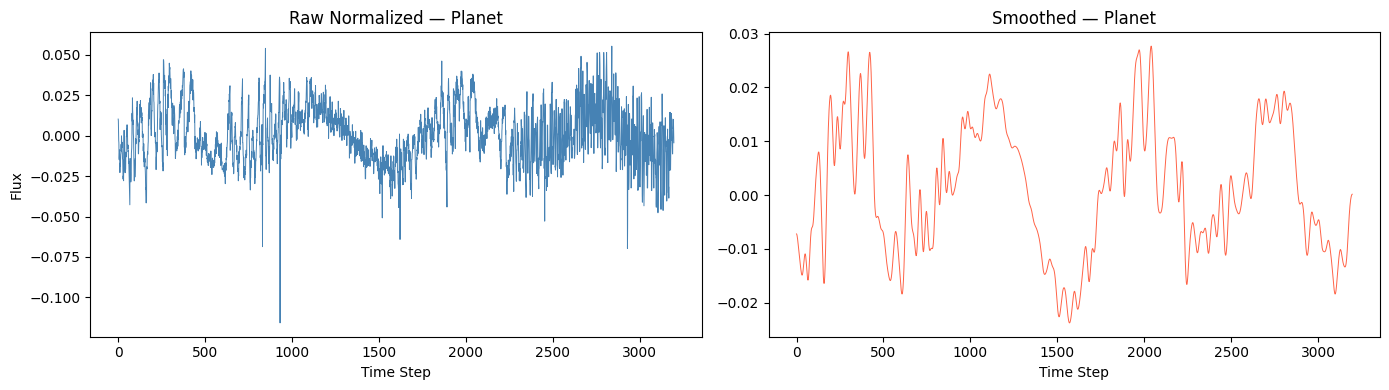

In [7]:
import matplotlib.pyplot as plt

# After remapping: 1 = planet, 0 = non-planet
planet_idx = list(y_train).index(1)

plt.figure(figsize=(14, 4))

plt.subplot(1, 2, 1)
plt.plot(X_train_norm[planet_idx], color='steelblue', linewidth=0.7)
plt.title("Raw Normalized — Planet")
plt.xlabel("Time Step")
plt.ylabel("Flux")

plt.subplot(1, 2, 2)
plt.plot(X_train_smooth[planet_idx], color='tomato', linewidth=0.7)
plt.title("Smoothed — Planet")
plt.xlabel("Time Step")

plt.tight_layout()
plt.savefig("../outputs/smooth_comparison.png", dpi=150)
plt.show()

## 6. Handle Class Imbalance (SMOTE)

The Kepler dataset is extremely imbalanced:
- Thousands of non-planet stars
- Very few confirmed planet stars

To solve this problem, **SMOTE (Synthetic Minority Oversampling Technique)** is used.

SMOTE:
- Generates synthetic planet samples
- Balances both classes equally
- Prevents CNN bias toward non-planet predictions

After SMOTE, both classes contain the same number of samples.

In [8]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train_smooth, y_train)

# After remapping: 0 = non-planet, 1 = planet
print("Before SMOTE:")
print(f"  Class 0 (non-planet): {sum(y_train == 0)}")
print(f"  Class 1 (planet)    : {sum(y_train == 1)}")

print("\nAfter SMOTE:")
print(f"  Class 0 (non-planet): {sum(y_train_resampled == 0)}")
print(f"  Class 1 (planet)    : {sum(y_train_resampled == 1)}")

print(f"\nNew X_train shape: {X_train_resampled.shape}")

C:\Software\anaconda\envs\exoplanet_clean\lib\site-packages\threadpoolctl.py:1226: RuntimeWarning: 
Found Intel OpenMP ('libiomp') and LLVM OpenMP ('libomp') loaded at
the same time. Both libraries are known to be incompatible and this
can cause random crashes or deadlocks on Linux when loaded in the
same Python program.
Using threadpoolctl may cause crashes or deadlocks. For more
information and possible workarounds, please see
    https://github.com/joblib/threadpoolctl/blob/master/multiple_openmp.md

  warnings.warn(msg, RuntimeWarning)


Before SMOTE:
  Class 0 (non-planet): 5050
  Class 1 (planet)    : 37

After SMOTE:
  Class 0 (non-planet): 5050
  Class 1 (planet)    : 5050

New X_train shape: (10100, 3197)


## 7. Train / Validation Split

The balanced dataset is divided into:
- Training set
- Validation set

A **stratified split** is used to preserve equal class distribution in both subsets.

Purpose:
- Train the CNN on one portion
- Validate performance on unseen samples
- Reduce overfitting risk

In [12]:
from sklearn.model_selection import train_test_split

X_train_final, X_val, y_train_final, y_val = train_test_split(
    X_train_resampled,
    y_train_resampled,
    test_size=0.2,
    random_state=42,
    stratify=y_train_resampled
)

print("X_train_final shape:", X_train_final.shape)
print("X_val shape        :", X_val.shape)
print()
print("Train class distribution:")
print(f"  Class 0 (non-planet): {sum(y_train_final == 0)}")
print(f"  Class 1 (planet)    : {sum(y_train_final == 1)}")
print()
print("Val class distribution:")
print(f"  Class 0 (non-planet): {sum(y_val == 0)}")
print(f"  Class 1 (planet)    : {sum(y_val == 1)}")

X_train_final shape: (8080, 3197)
X_val shape        : (2020, 3197)

Train class distribution:
  Class 0 (non-planet): 4040
  Class 1 (planet)    : 4040

Val class distribution:
  Class 0 (non-planet): 1010
  Class 1 (planet)    : 1010


## 8. Save Preprocessed Data

Finally, all processed datasets are saved into the `data/processed/` directory.

Saved files include:
- Training data
- Validation data
- Test data
- Labels

Two dataset versions are stored:
1. **SMOTE-balanced dataset** → for CNN training
2. **Real distribution dataset** → for realistic evaluation

This ensures flexibility during model experimentation.

In [10]:
import numpy as np

np.save("../data/processed/X_train_final.npy", X_train_final)
np.save("../data/processed/X_val.npy",         X_val)
np.save("../data/processed/X_test_smooth.npy", X_test_smooth)
np.save("../data/processed/y_train_final.npy", y_train_final)
np.save("../data/processed/y_val.npy",         y_val)
np.save("../data/processed/y_test.npy",        y_test)

print("All files saved to data/processed/ ✅")

All files saved to data/processed/ ✅


In [11]:
# ── Save a second version: NO SMOTE, real distribution preserved ──
from sklearn.model_selection import train_test_split

# Use original (pre-SMOTE) smoothed data
X_tr_real, X_v_real, y_tr_real, y_v_real = train_test_split(
    X_train_smooth, y_train,          # original, not resampled
    test_size=0.2,
    random_state=42,
    stratify=y_train
)

np.save("../data/processed/X_train_real.npy", X_tr_real)
np.save("../data/processed/X_val_real.npy",   X_v_real)
np.save("../data/processed/y_train_real.npy", y_tr_real)
np.save("../data/processed/y_val_real.npy",   y_v_real)

print("Real distribution train shape:", X_tr_real.shape)
print("Real distribution val shape:  ", X_v_real.shape)
print(f"Train — Class 0: {sum(y_tr_real==0)}, Class 1: {sum(y_tr_real==1)}")
print(f"Val   — Class 0: {sum(y_v_real==0)}, Class 1: {sum(y_v_real==1)}")

Real distribution train shape: (4069, 3197)
Real distribution val shape:   (1018, 3197)
Train — Class 0: 4039, Class 1: 30
Val   — Class 0: 1011, Class 1: 7


## Summary : What we learned

- No missing values found in train or test data
- 3197 flux features per light curve after dropping LABEL
- L2 normalization applied per row to fix brightness scale differences across stars
- Gaussian smoothing (σ=10) removed high-frequency noise while preserving transit dips
- Two clear transit dips visible at timestep ~900 and ~2600 on first planet sample
- SMOTE resolved severe 136:1 class imbalance → balanced 1:1 (5050 vs 5050)
- Stratified split ensured perfect 50/50 class ratio in both train and validation sets
- Test data kept completely untouched and unbalanced — represents real world distribution